# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Joe Whibley
* Username: jcbwhibley
* Student number: s6411258
* Group (AS1, etc.): AS6

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

this is the expected keplerian curve, it does not follow at higher radii which suggests the presence of dark matter


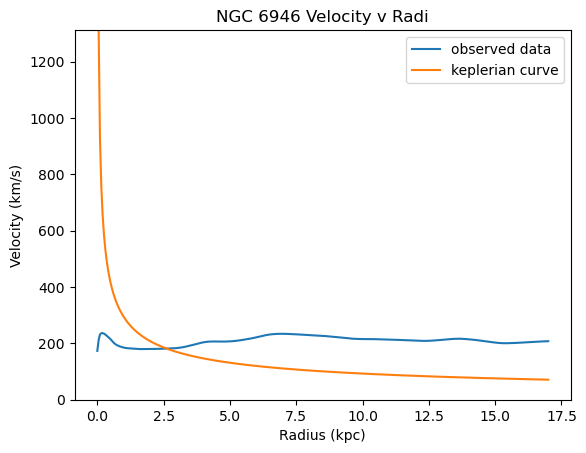

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

G=scipy.constants.G     #m^3 kg^-1 s^-2
M_sun=1.989e30     #solar mass

data = np.genfromtxt('rotcur.dat.txt', comments='#')           #gets array from text
arr = data.reshape(341, 2)                 #reshapes into 2 columns

radii_kpc = arr[:,0]   #split w slicing :=all rows, 0=column index
rotv_kms = arr[:,1]


radii_m = radii_kpc*3.086e19   
M_kg = (2*10**10)*M_sun        


radi_vk_kpc = radii_kpc[1:] 
radi_vk_m = radii_m[1:]                #take all but the first so as to avoid divided by 0 error
vk_ms = np.sqrt(G*M_kg/radi_vk_m)
vk_kms = vk_ms/1000   

max_kep = np.max(vk_kms)     #max value for graphing


np.savetxt('keplerian_curve.txt', vk_kms)        
data_vk= np.loadtxt('keplerian_curve.txt', comments='#')


plt.plot(radii_kpc, rotv_kms, label='observed data')
plt.plot(radi_vk_kpc, data_vk, label='keplerian curve')
plt.ylim(0, max_kep)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title('NGC 6946 Velocity v Radi')
plt.legend()

print("this is the expected keplerian curve, it does not follow at higher radii which suggests the presence of dark matter")


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

the mean and standard distribution of the 2d slice is 0.026768063034257158 and 0.9734457505676172 respectively
this is a normal distribution


(array([2.000e+00, 3.000e+00, 3.000e+00, 1.000e+00, 5.000e+00, 1.800e+01,
        3.300e+01, 5.600e+01, 9.000e+01, 1.460e+02, 1.900e+02, 3.020e+02,
        4.220e+02, 6.050e+02, 8.210e+02, 1.127e+03, 1.442e+03, 1.801e+03,
        2.203e+03, 2.618e+03, 3.086e+03, 3.400e+03, 3.635e+03, 3.853e+03,
        4.003e+03, 4.077e+03, 3.971e+03, 3.723e+03, 3.437e+03, 3.141e+03,
        2.607e+03, 2.215e+03, 1.766e+03, 1.420e+03, 1.061e+03, 8.250e+02,
        6.140e+02, 4.680e+02, 2.810e+02, 2.080e+02, 1.300e+02, 7.200e+01,
        5.500e+01, 2.900e+01, 1.800e+01, 8.000e+00, 4.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00]),
 array([-4.22594489e+00, -4.05689659e+00, -3.88784830e+00, -3.71880001e+00,
        -3.54975171e+00, -3.38070342e+00, -3.21165512e+00, -3.04260683e+00,
        -2.87355854e+00, -2.70451024e+00, -2.53546195e+00, -2.36641365e+00,
        -2.19736536e+00, -2.02831706e+00, -1.85926877e+00, -1.69022048e+00,
        -1.52117218e+00, -1.35212389e+00, -1.18307559e+00, -1.01402730e+

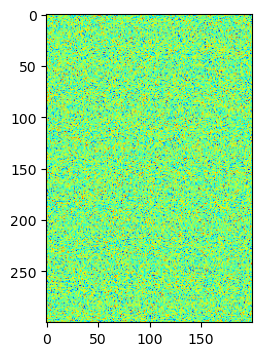

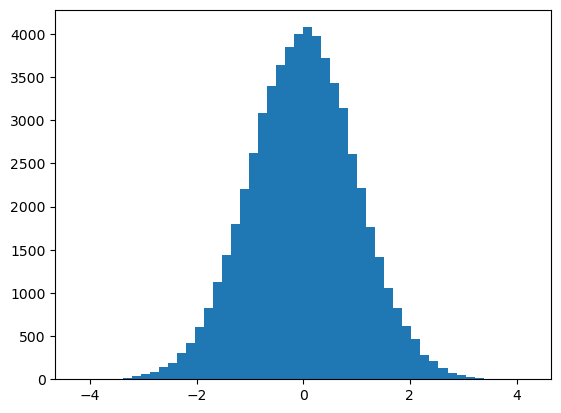

In [40]:
import numpy as np
from imageio import imwrite, imread
from matplotlib.pyplot import subplots, show
import matplotlib.pyplot as plt

a = np.random.normal(0,1,(200*300))
arr = np.reshape(a,(300,200))    #reshaping the data

arr2=arr[0:30,0:30]
mean=np.mean(arr2)
std=np.std(arr2)
print(f"the mean and standard distribution of the 2d slice is {mean} and {std} respectively")


hist= arr.flatten()    #turns 2d data into 1d
  
print("this is a normal distribution")    #change to label!!!!

plt.figure(figsize=(8,4))
plt.imshow(arr, cmap='jet')
plt.figure()  #adds diff figure
plt.hist(hist, 50)



#TODO: check if the 2d array is goated or nah

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

area: 18.84955592153876, perimeter: 15.865437575563961
center (x,y): ((20, 20)), position angle: 0, semi major: 3, semi minor: 2


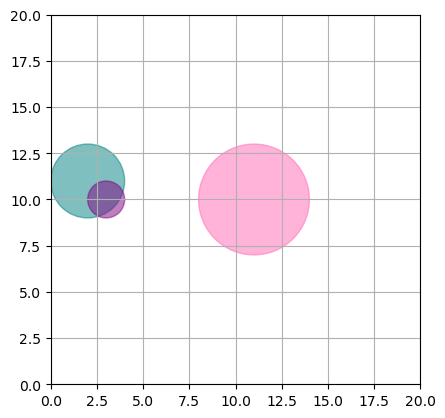

In [90]:
from matplotlib.patches import Ellipse
from matplotlib.pyplot import show, figure
import math
import numpy as np

pi = math.pi

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      pi = math.pi
      self.semi_major = semi_major
      self.semi_minor = semi_minor
      self.position_angle = position_angle
      
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)  # MPL requires center as a tuple
      self.XY = XY
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)
      
    def area(self):
        area = pi*self.semi_major*self.semi_minor
        self.area=area     #not neccesary just so i could call it in other methods if hypothetically needed
        return(area)
      #perimeter = pi*((semi_major+semi_minor)+((3(semi_major-semi_minor)**2)/(10(semi_major+semi_minor)+(semi_major**2+14*semi_major*semi_minor+semi_minor**2)**0.5))+epsilon)
    def perimeter(self):
        perimeter = pi*(3*(self.semi_major+self.semi_minor)-((3*self.semi_major+self.semi_minor)*(self.semi_major+3*self.semi_minor))**0.5)
        self.perimeter = perimeter   
        return(perimeter)
    def __str__(self):
        return(f"center (x,y): ({self.XY}), position angle: {self.position_angle}, semi major: {self.semi_major}, semi minor: {self.semi_minor}")

eg_a=3
eg_b=2
eg_ellipse=AstroEllipse(semi_major=eg_a, semi_minor=eg_b, position_angle=0, xc=20, yc=20)

eg_area = eg_ellipse.area()
eg_perimeter = eg_ellipse.perimeter()

print(f"area: {eg_area}, perimeter: {eg_perimeter}")

stringg = eg_ellipse.__str__()
print(stringg)


class MyCircle(AstroEllipse):
    def __init__(self, XY, radius, **args):
        (xc, yc)=XY
        super().__init__(xc, yc, semi_major=radius, semi_minor=radius, position_angle=0, **args)  

#fig = figure()
#frame=fig.add_subplot(1,1,1, aspect=1)

fig, ax = plt.subplots()
ax.set_aspect('equal')

XY1= (np.random.randint(0,15), np.random.randint(0,15))
XY2 = (np.random.randint(0,15),np.random.randint(0,15))
XY3 = (np.random.randint(0,15),np.random.randint(0,15))


circle1=MyCircle(XY1, np.random.randint(1,5), alpha=0.5, color='hotpink')
circle2=MyCircle(XY2, np.random.randint(1,5), alpha=0.5, color='teal')
circle3=MyCircle(XY3, np.random.randint(1,5), alpha = 0.5, color='purple')


ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.grid()
ax.set_xlim(0,20)
ax.set_ylim(0,20)
show()




In [83]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

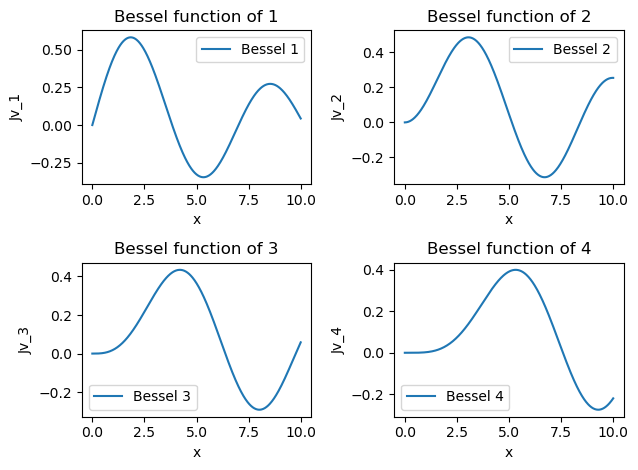

In [35]:
from scipy.special import jv
import numpy as np
import math
import matplotlib.pyplot as plt

x=np.linspace(0,10,500)     #making a x range to iterate jv over
a=[1,2,3,4]                #list of different orders

fig, axes = plt.subplots(2,2) #creating subplots for different orders


axes_flat = axes.flatten()   #flattens the axes array into 1d so we can put it in a loop

for i, b in enumerate(a):       #loops over (index, value)
    ax = axes_flat[i]
    
    y = jv(b, x)
    ax.plot(x, y, label=f"Bessel {b}")
    ax.set_title(f"Bessel function of {b}")
    ax.set_ylabel(f"Jv_{b}")
    ax.set_xlabel("x")
    ax.legend()
    
fig.tight_layout()     #makes the stuff not overlapping 
plt.savefig('bessel.png', transparent=True)
plt.show()




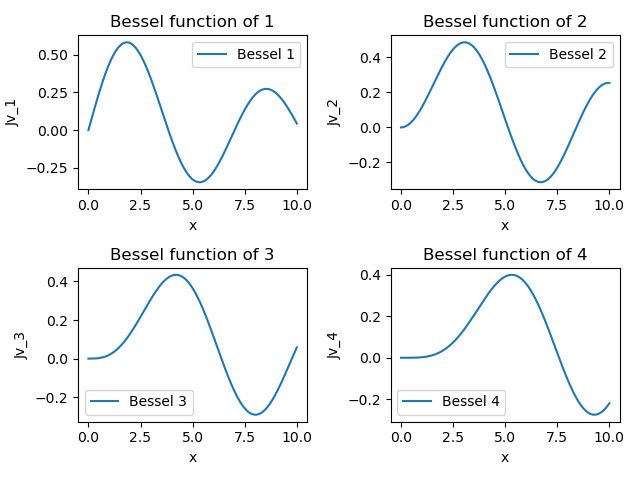

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

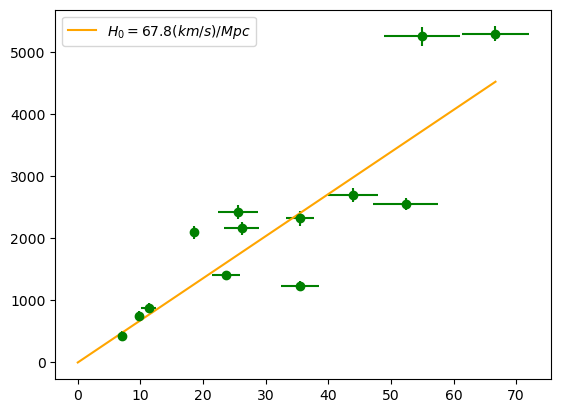

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_ = np.array([
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ])                                    #remember nested brackets () for np.array([])

data=data_.reshape(13,4)

d = data[:,0]  #[row index(all), column index(0)]
v = data[:,1]
erd = data[:,2]
erv = data[:,3]

m = 67.8
x_ = np.linspace(0, d.max(), 13)
y_ = m*x_ 


fig, ax = plt.subplots()
ax.errorbar(d, v, xerr=erd, yerr=erv, fmt='o', color='green')  #fmt makes it scatter
ax.plot(x_, y_, color='orange', label=rf"$H_0 = 67.8 (km/s)/Mpc$")
ax.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")